# Notebook: Black–Litterman

ใช้ Python 3 standard library และกด Run All ตามลำดับได้ ตัวเลขเป็นข้อมูลสมมติ ภาพประกอบฝังอยู่ในไฟล์แล้ว

# Black–Litterman

ถ้าเราคิดต่างจากตลาด ควรปรับพอร์ตไปไกลแค่ไหน?

> “เราเชื่อว่าข้อมูลเกี่ยวกับผลตอบแทนส่วนเกินในอนาคตมีสองแหล่งที่แตกต่างกัน คือมุมมองของผู้ลงทุนและดุลยภาพตลาด”
>
> <span lang="en">“We believe there are two distinct sources of information about future excess returns—investor views and market equilibrium.”</span>
>
> — **Fischer Black และ Robert Litterman** · [*Global Portfolio Optimization (1992), น. 34*](https://people.duke.edu/~charvey/Teaching/BA453_2005/blacklitterman.pdf#page=7)

สมมติเราคาดว่าสินทรัพย์ X3 จะให้ผลตอบแทนมากกว่า X1 อยู่ 10 จุดเปอร์เซ็นต์ แต่ยังไม่มั่นใจว่าประมาณได้แม่นแค่ไหน ถ้าใส่ตัวเลขนี้ลงใน optimizer โดยตรง น้ำหนักพอร์ตอาจเปลี่ยนไปมาก เราต้องการวิธีระบุทั้งมุมมองและความไม่แน่นอนของมุมมองนั้น

Black–Litterman เริ่มจากผลตอบแทนคาดหมายที่สอดคล้องกับพอร์ตตลาด แล้วปรับด้วย views ของผู้ลงทุน มุมมองที่มีความไม่แน่นอนสูงจะดึงค่าประมาณออกจากจุดตั้งต้นได้น้อยกว่า เมื่อได้ผลตอบแทนชุดใหม่ จึงนำไปคำนวณน้ำหนักด้วยโจทย์จัดพอร์ตจากบท [Optimization Problem](../portfolio-optimization.html)

เราจะใช้สินทรัพย์สมมติสี่ตัวจากบทก่อน โดยเขียนค่าเฉลี่ยเป็น **ผลตอบแทนส่วนเกินเหนืออัตราปลอดความเสี่ยง** ทุกครั้งที่อ่าน Q หรือ posterior จึงต้องแยกออกจากผลตอบแทนรวม ตัวอย่างเป็น simple return ระยะหนึ่งปี

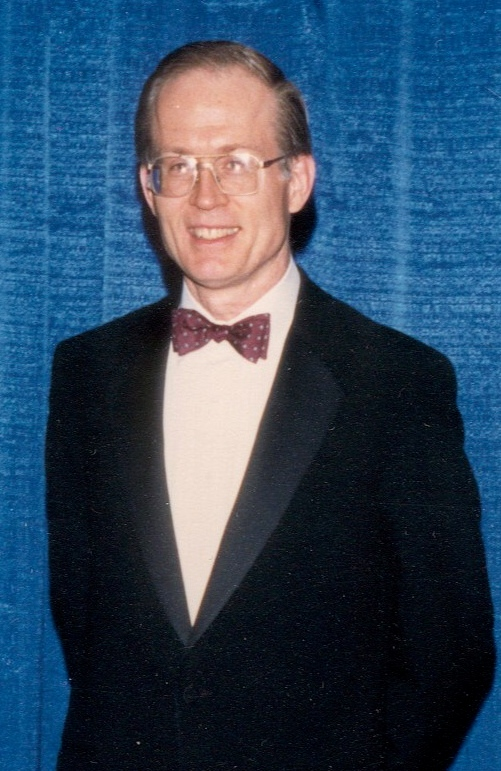

**Fischer Black และงานร่วมกับ Robert Litterman**
บทความ <em>Global Portfolio Optimization</em> ปี 1992 ใช้ข้อมูลจากดุลยภาพตลาดร่วมกับมุมมองผู้ลงทุน เป็นที่มาของแบบจำลองที่เราจะคำนวณในบทนี้ อ่านเรื่องการร่วมงานจาก [บทสัมภาษณ์ Robert Litterman](https://www.minneapolisfed.org/article/2019/interview-with-robert-litterman) ได้เพิ่มเติม
<small>บุคคลในภาพ: Fischer Black · ภาพโดย Dalmatine เผยแพร่เป็นสาธารณสมบัติผ่าน [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Fischer_Black.JPG) · ไม่ทราบวันที่ถ่าย</small>

In [1]:
import itertools
import math

def close(actual, expected, tol=1e-9):
    assert math.isclose(actual, expected, rel_tol=tol, abs_tol=tol), (actual, expected)

def dot(a, b):
    return sum(x*y for x, y in zip(a, b))

def transpose(a):
    return [list(column) for column in zip(*a)]

def matmul(a, b):
    bt = transpose(b)
    return [[dot(row, column) for column in bt] for row in a]

def matvec(a, x):
    return [dot(row, x) for row in a]

def solve(a, b):
    augmented = [list(row) + [value] for row, value in zip(a, b)]
    n = len(augmented)
    assert all(len(row) == n + 1 for row in augmented)
    for column in range(n):
        pivot = max(range(column, n), key=lambda row: abs(augmented[row][column]))
        assert abs(augmented[pivot][column]) > 1e-14, "singular system"
        augmented[column], augmented[pivot] = augmented[pivot], augmented[column]
        scale = augmented[column][column]
        augmented[column] = [value/scale for value in augmented[column]]
        for row in range(n):
            if row == column:
                continue
            factor = augmented[row][column]
            augmented[row] = [left-factor*right for left, right in zip(augmented[row], augmented[column])]
    return [row[-1] for row in augmented]

def variance(weights, covariance):
    return dot(weights, matvec(covariance, weights))

MU = [.05, .07, .15, .27]
SD = [.07, .12, .30, .60]
CORR = [
    [1, .8, .5, .4],
    [.8, 1, .7, .5],
    [.5, .7, 1, .8],
    [.4, .5, .8, 1],
]
SIGMA = [[CORR[i][j]*SD[i]*SD[j] for j in range(4)] for i in range(4)]
ONE = [1.0]*4
RF = .025
print("Hypothetical one-year simple returns. Python standard library only.")

Hypothetical one-year simple returns. Python standard library only.


## ข้อมูลที่ใช้ร่วมกับบทก่อน

ใช้ volatility ของ X1–X4 เท่ากับ 7%, 12%, 30%, 60% ตามลำดับ และ covariance ต่อปี

$$
\Sigma=
\begin{pmatrix}
0.0049&0.00672&0.0105&0.0168\\
0.00672&0.0144&0.0252&0.0360\\
0.0105&0.0252&0.0900&0.1440\\
0.0168&0.0360&0.1440&0.3600
\end{pmatrix}.
$$

อัตราปลอดความเสี่ยง \(r=2.5\%\) ต่อปี ดู [การสร้าง covariance จาก volatility และ correlation](../portfolio-optimization.html#covariance-inputs) หากต้องการทบทวนที่มา เราจะหา expected excess returns จากน้ำหนักตลาด จึงไม่ใช้เวกเตอร์ expected returns 5%, 7%, 15%, 27% ของบทก่อนเป็น prior โดยตรง

In [2]:
expected_sigma = [
    [.0049, .00672, .0105, .0168],
    [.00672, .0144, .0252, .036],
    [.0105, .0252, .09, .144],
    [.0168, .036, .144, .36],
]
for row, expected in zip(SIGMA, expected_sigma):
    for actual, target in zip(row, expected):
        close(actual, target, 1e-12)
print("Sigma = diag(SD) @ Corr @ diag(SD)")
for row in SIGMA:
    print("  ", [round(value, 6) for value in row])

Sigma = diag(SD) @ Corr @ diag(SD)
   [0.0049, 0.00672, 0.0105, 0.0168]
   [0.00672, 0.0144, 0.0252, 0.036]
   [0.0105, 0.0252, 0.09, 0.144]
   [0.0168, 0.036, 0.144, 0.36]


## Black–Litterman ตั้งต้นจากพอร์ตตลาด

น้ำหนัก mean–variance ไวต่อ \(\boldsymbol\mu\) มาก ผลตอบแทนคาดหวังที่ต่างกันไม่กี่จุดอาจเปลี่ยน long–short positions ขนาดใหญ่ [Black–Litterman](../glossary.html#black-litterman) เริ่มจากน้ำหนักตลาดที่สังเกตได้ แล้วใช้ reverse optimization หา expected excess returns ที่สอดคล้องกับน้ำหนักนั้น ก่อนผสม views ที่ระบุพร้อมความไม่แน่นอน



Roadmap แยกข้อมูลตลาด ความเห็น และการจัดสรรออกจากกัน จึงย้อนตรวจได้ว่าการเปลี่ยนน้ำหนักมาจาก input ส่วนใด [ดาวน์โหลดไฟล์ Excalidraw ที่แก้ไขต่อได้](../assets/diagrams/optimization-black-litterman-roadmap.excalidraw)

### 1. Reverse optimization หา prior

สมมติพอร์ตตลาดมีน้ำหนัก

$$
\mathbf w_{\mathrm{mkt}}=
\begin{pmatrix}
0.05&0.40&0.45&0.10
\end{pmatrix}^{\!\top}.
$$

จากคำตอบ mean–variance \(\mathbf w^*=\lambda^{-1}\Sigma^{-1}\widetilde{\boldsymbol\mu}\) เราแก้ย้อนกลับเพื่อหา implied equilibrium excess returns

$$
\boxed{
\boldsymbol\Pi=
\lambda_{\mathrm{mkt}}\Sigma\mathbf w_{\mathrm{mkt}}.
}
$$

ตัวอย่างกำหนด market Sharpe ratio เท่ากับ 0.5 พอร์ตตลาดมี volatility ประมาณ 22.3523% จึงใช้

$$
\lambda_{\mathrm{mkt}}
=\frac{\operatorname{SR}_{\mathrm{mkt}}}
{\sigma_{\mathrm{mkt}}}
\approx2.24.
$$

ผลที่คำนวณด้วย \(\lambda_{\mathrm{mkt}}=2.24\) คือ

$$
\boldsymbol\Pi\approx
\begin{pmatrix}
0.020917\\
0.047121\\
0.146731\\
0.259930
\end{pmatrix}.
$$

เราเขียน prior ของ excess returns เป็น

$$
\widetilde{\boldsymbol\mu}
\sim N(\boldsymbol\Pi,\tau\Sigma).
$$

ตัวอย่างกำหนด \(\tau=1/120\) เพื่อประกอบตัวอย่าง เลข 120 เทียบกับจำนวนเดือนในสิบปี แต่ \(\Sigma\) ชุดนี้ประมาณจากข้อมูลดังกล่าว วิธีตั้ง \(\tau\) ไม่มีคำตอบเดียวและต้องสอดคล้องกับนิยามของ \(\Omega\) ที่ใช้กับ views

### 2. เขียน views เป็น \(P,Q,\Omega\)

กำหนดสอง views

1. \(X_3\) จะให้ excess return สูงกว่า \(X_1\) อยู่ 10 จุดเปอร์เซ็นต์
2. \(X_2\) จะให้ excess return 3%

จึงได้

$$
P=
\begin{pmatrix}
-1&0&1&0\\
0&1&0&0
\end{pmatrix},
\qquad
Q=
\begin{pmatrix}
0.10\\0.03
\end{pmatrix}.
$$

แถวแรกของ \(P\) รวมเป็นศูนย์เพราะเป็น relative view ส่วนแถวที่สองเลือก \(X_2\) ตัวเดียวและเป็น absolute view เขียนแบบจำลองของ views เป็น

$$
Q=P\widetilde{\boldsymbol\mu}+\boldsymbol\varepsilon_v,
\qquad
\boldsymbol\varepsilon_v\sim N(\mathbf 0,\Omega).
$$

ตัวอย่างใช้

$$
\Omega_{ii}=\left[P(\tau\Sigma)P^\top\right]_{ii},
\qquad
\Omega_{ij}=0\quad(i\ne j).
$$

ค่าแนวทแยงเล็กลงทำให้ view มีน้ำหนักมากขึ้น ค่าใหญ่ขึ้นทำให้ posterior อยู่ใกล้ prior มากขึ้น การเรียกค่าหนึ่งว่า “มั่นใจ 80%” ต้องมี mapping เพิ่มเติม เช่นวิธีของ Idzorek จึงไม่ควรติดป้ายเปอร์เซ็นต์ให้ \(\Omega\) โดยตรง

### 3. ผสมเป็น posterior

Posterior mean เขียนในรูปที่คำนวณได้เสถียรว่า

$$
\boxed{
\widehat{\boldsymbol\mu}_{\mathrm{BL}}
=\boldsymbol\Pi
+\tau\Sigma P^\top
\left(P\tau\Sigma P^\top+\Omega\right)^{-1}
(Q-P\boldsymbol\Pi).
}
$$

สูตรนี้เทียบเท่ากับ precision form

$$
\widehat{\boldsymbol\mu}_{\mathrm{BL}}
=\left[(\tau\Sigma)^{-1}+P^\top\Omega^{-1}P\right]^{-1}
\left[(\tau\Sigma)^{-1}\boldsymbol\Pi+P^\top\Omega^{-1}Q\right].
$$

สำหรับตัวอย่าง

$$
\widehat{\boldsymbol\mu}_{\mathrm{BL}}
\approx
\begin{pmatrix}
0.016782\\
0.037552\\
0.124843\\
0.227174
\end{pmatrix}.
$$



Posterior ขยับทั้งสี่สินทรัพย์เพราะ covariance เชื่อม views เข้ากับสินทรัพย์อื่น เส้นทางการขยับจึงไม่ได้จำกัดอยู่ที่ช่องของ \(P\) เท่านั้น

### 4. แปลง posterior เป็นน้ำหนัก

เมื่อใช้ risk aversion \(\lambda\)

$$
\mathbf w_{\mathrm{BL}}
=\frac1\lambda
\Sigma^{-1}\widehat{\boldsymbol\mu}_{\mathrm{BL}}.
$$

ที่ \(\lambda=2.24\) น้ำหนักสินทรัพย์เสี่ยงและสินทรัพย์ปลอดความเสี่ยงเป็น

| น้ำหนัก | \(X_1\) | \(X_2\) | \(X_3\) | \(X_4\) | สินทรัพย์ปลอดความเสี่ยง |
|---|---:|---:|---:|---:|---:|
| พอร์ตตลาด | 5.00% | 40.00% | 45.00% | 10.00% | 0.00% |
| Black–Litterman | 9.87% | 16.59% | 40.13% | 10.00% | 23.41% |



Risk aversion เปลี่ยนขนาดรวมของ risky allocation ส่วน \(P,Q,\Omega\) และ covariance เปลี่ยนทิศทางสัมพัทธ์ของน้ำหนัก เมื่อกำหนดแบบนี้ \(\Omega\) เปลี่ยนตาม \(\tau\) ทำให้ \(\tau\) หักล้างจาก posterior mean; ถ้ากำหนด \(\Omega\) แยกต่างหาก \(\tau\) จะมีผล

Posterior covariance ของค่าเฉลี่ยและ covariance ของผลตอบแทนเป็นคนละวัตถุ สูตรจัดพอร์ตข้างบนใช้ \(\Sigma\) เป็น covariance ของผลตอบแทน การนำ posterior uncertainty ไปบวกหรือใช้แทน \(\Sigma\) เป็นการเลือกแบบจำลองอีกแบบหนึ่ง ซึ่งจะให้โจทย์จัดพอร์ตต่างออกไป

In [3]:
MARKET = [.05, .40, .45, .10]
LAMBDA_MARKET = 2.24
TAU = 1/120
P = [[-1, 0, 1, 0], [0, 1, 0, 0]]
Q = [.10, .03]
prior = [LAMBDA_MARKET*value for value in matvec(SIGMA, MARKET)]
tau_sigma = [[TAU*value for value in row] for row in SIGMA]
projected = matmul(matmul(P, tau_sigma), transpose(P))
omega = [[projected[i][i] if i == j else 0.0 for j in range(2)] for i in range(2)]
system = [[projected[i][j]+omega[i][j] for j in range(2)] for i in range(2)]
innovation = [q-p for q, p in zip(Q, matvec(P, prior))]
view_update = solve(system, innovation)
posterior_adjustment = matvec(matmul(tau_sigma, transpose(P)), view_update)
posterior = [base+change for base, change in zip(prior, posterior_adjustment)]
expected_posterior = [.016781811019405, .037552435573995, .124842704859425, .227173738447279]
for actual, target in zip(posterior, expected_posterior):
    close(actual, target)
weights = [value/LAMBDA_MARKET for value in solve(SIGMA, posterior)]
risk_free = 1-sum(weights)
close(risk_free, .234140487785057)
print("Prior excess returns:", [f"{100*x:.4f}%" for x in prior])
print("Posterior excess returns:", [f"{100*x:.4f}%" for x in posterior])
print("Posterior risky weights:", [f"{100*x:.4f}%" for x in weights])
print(f"Risk-free weight={100*risk_free:.4f}%")

Prior excess returns: ['2.0917%', '4.7121%', '14.6731%', '25.9930%']
Posterior excess returns: ['1.6782%', '3.7552%', '12.4843%', '22.7174%']
Posterior risky weights: ['9.8696%', '16.5860%', '40.1304%', '10.0000%']
Risk-free weight=23.4140%


## ทดลองผสม views กับพอร์ตตลาด

ห้องทดลองใช้ \(\Sigma\), market weights, \(\tau=1/120\), \(P\) และ \(Q\) ชุดเดียวกับตัวอย่าง เปิดหรือปิดแต่ละ view เปลี่ยนค่า Q และความไม่แน่นอนแยกกัน แล้วเปรียบเทียบผลตอบแทนส่วนเกินกับน้ำหนักพอร์ต ปุ่มปิด views ทั้งหมดใช้ตรวจจุดตั้งต้น ก่อนลองปรับ risk aversion ของผู้ลงทุน

ตัวคูณ \(\Omega\) ต่ำทำให้ views มีน้ำหนักมากขึ้น ตัวคูณสูงดึง posterior กลับเข้าหา market-implied prior ส่วน \(\lambda\) เปลี่ยนขนาด risky allocation หลังคำนวณ posterior แล้ว ห้องทดลองไม่ใช้ข้อมูลตลาด ไม่รวมค่าธรรมเนียม ภาษี turnover หรือข้อจำกัด long-only

In [4]:
def update_views(q_values, enabled=(True, True), scales=(1, 1), investor_lambda=2.24):
    indices = [i for i in range(2) if enabled[i]]
    if not indices:
        updated = prior[:]
    else:
        rows = [P[i] for i in indices]
        projected = matmul(matmul(rows, tau_sigma), transpose(rows))
        system = [[projected[i][j] + (scales[indices[i]]*projected[i][i] if i == j else 0)
                   for j in range(len(indices))] for i in range(len(indices))]
        delta = solve(system, [q_values[i]-dot(P[i],prior) for i in indices])
        correction = matvec(matmul(tau_sigma,transpose(rows)),delta)
        updated = [p+d for p,d in zip(prior,correction)]
    weights = [x/investor_lambda for x in solve(SIGMA,updated)]
    return updated, weights, 1-sum(weights)

no_views, market_again, cash = update_views(Q, enabled=(False,False))
for actual, expected in zip(market_again, MARKET):
    close(actual, expected)
close(cash, 0)
for enabled, scales, q in [((True,False),(.25,1),Q), ((True,True),(1,4),Q), ((True,True),(1,1),[-.10,-.05])]:
    updated, weights, cash = update_views(q, enabled, scales)
    print(f"views={enabled}, Omega multipliers={scales}, Q={q}")
    print("Posterior:", updated, "Weights:", weights, "Risk-free:", cash)


views=(True, False), Omega multipliers=(0.25, 1), Q=[0.1, 0.03]
Posterior: [0.01935220689580515, 0.041956426756156975, 0.12451502289580516, 0.2243837166332883] Weights: [0.17475391455634762, 0.40000000000000074, 0.32524608544364936, 0.10000000000000021] Risk-free: 2.1094237467877974e-15
views=(True, True), Omega multipliers=(1, 4), Q=[0.1, 0.03]
Posterior: [0.018738962945067977, 0.04148291528176221, 0.12980395195195196, 0.23370722176925535] Weights: [0.11684339966462798, 0.31100171067582616, 0.38315660033537097, 0.10000000000000021] Risk-free: 0.08899828932417464
views=(True, True), Omega multipliers=(1, 1), Q=[-0.1, -0.05]
Posterior: [-0.003293417141624122, -0.012552462102955665, -0.014415213958894224, 0.013329599034882567] Weights: [0.5869116275778682, -0.7609479754788049, -0.08691162757786783, 0.1000000000000001] Risk-free: 1.1609479754788046


## สิ่งที่ต้องตรวจเมื่อใช้ posterior

- ใช้หน่วยเวลาเดียวกันใน \(\Sigma,\Pi,Q\) และแยก excess return ออกจาก total return
- ตรวจว่า \(P\) แทน view ที่ตั้งใจ และ \(\Omega\) อธิบายความไม่แน่นอนของ view ไม่ใช่ covariance ของผลตอบแทน
- ทดลองขยับ views และความไม่แน่นอนเล็กน้อย แล้วดูทั้งน้ำหนัก เงินกู้ และ gross exposure
- สูตร allocation นี้อนุญาต short และ borrowing หากต้องการ long-only หรือเพดานน้ำหนัก ต้องแก้ [โจทย์ที่มี constraints](../portfolio-optimization.html#inequality-constraints) เพิ่ม
- แยก posterior uncertainty ของค่าเฉลี่ยจาก return covariance; บทนี้ใช้ \(\Sigma\) เดิมสำหรับ allocation

## ลองคำนวณต่อ

1. ทำไมแถว relative view ของ \(P\) จึงรวมเป็นศูนย์ ส่วน absolute view ของสินทรัพย์หนึ่งตัวรวมเป็นหนึ่ง?
2. เมื่อใช้ prior \(\Pi=2.24\Sigma w_{mkt}\) ใน optimizer ที่ \(\lambda=2.24\) และยังไม่ใส่ views จะได้น้ำหนักใด?
3. จาก posterior risky weights 9.8696%, 16.5860%, 40.1304%, 10% จงหาน้ำหนักสินทรัพย์ปลอดความเสี่ยง

**ดูแนวคำตอบ**

1. Relative view เปรียบเทียบสองขาที่หักล้างน้ำหนักกัน ส่วน absolute view เลือกสินทรัพย์หนึ่งตัวด้วยน้ำหนักหนึ่ง
2. ได้ \(w_{mkt}\) เดิม เพราะ \((1/2.24)\Sigma^{-1}(2.24\Sigma w_{mkt})=w_{mkt}\)
3. Risky weights รวมประมาณ 76.5860% จึงเหลือ risk-free weight ประมาณ 23.4140%

## ทำต่อใน Python

[ดาวน์โหลด Notebook ของบท Black–Litterman](black-litterman.ipynb) เพื่อสร้าง covariance, คำนวณ prior, views, posterior และ allocation พร้อมตรวจตัวเลขในบท ทุกเซลล์ใช้ Python standard library และมีภาพฝังอยู่ในไฟล์

## เอกสารประกอบ

- *Fundamentals of Optimization and Application to Portfolio Selection*, CQF, หัวข้อ Black–Litterman
- Fischer Black and Robert Litterman, “Global Portfolio Optimization,” *Financial Analysts Journal*, 48(5), 28–43, 1992
- Jay Walters, *The Black–Litterman Model in Detail*, working paper, 2011 ใช้เป็นที่มาของตัวอย่าง views ตามรายการอ้างอิงในเอกสารประกอบ

[ข้อมูลสมมติและวิธีตรวจตัวเลข](../data/black-litterman-provenance.json)